# Step 1: Import Required Libraries

In this step, we import all the libraries required for data analysis,
preprocessing, visualization, and building the Linear Regression model.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# Step 2: Load the Dataset

Now we load the marketing campaign dataset using Pandas and display
the first few rows.

In [12]:
df = pd.read_excel("marketing_campaign.xlsx")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


# Step 3: Check Dataset Shape

Display the number of rows and columns present in the dataset.

In [13]:
print("Rows and Columns :", df.shape)

Rows and Columns : (2240, 29)


# Step 4: Explore the Dataset

Let's check the number of rows, columns,
data types, and missing values.

In [14]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [15]:
df.describe()



,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [16]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

# Step 5: Check Duplicate Records

Duplicate records can reduce the quality of
machine learning models.

In [17]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# Step 6: Handle Missing Values

The Income column contains some missing values.
We replace them with the median value.

In [18]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Step 7: Remove Unnecessary Columns

The ID column is only an identifier,
so it is removed before training the model.

In [19]:
df = df.drop("ID", axis=1)

# Step 8: Convert Date Column

Convert the customer joining date into datetime format.

In [20]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

df["Customer_Year"] = df["Dt_Customer"].dt.year
df["Customer_Month"] = df["Dt_Customer"].dt.month

df.drop("Dt_Customer", axis=1, inplace=True)

# Step 9: Encode Categorical Data

Machine Learning models cannot understand text values.
We convert them into numbers using Label Encoding.

In [21]:
encoder = LabelEncoder()

df["Education"] = encoder.fit_transform(df["Education"])

df["Marital_Status"] = encoder.fit_transform(df["Marital_Status"])

# Step 10: Correlation Matrix

Visualize the relationship between numerical features.

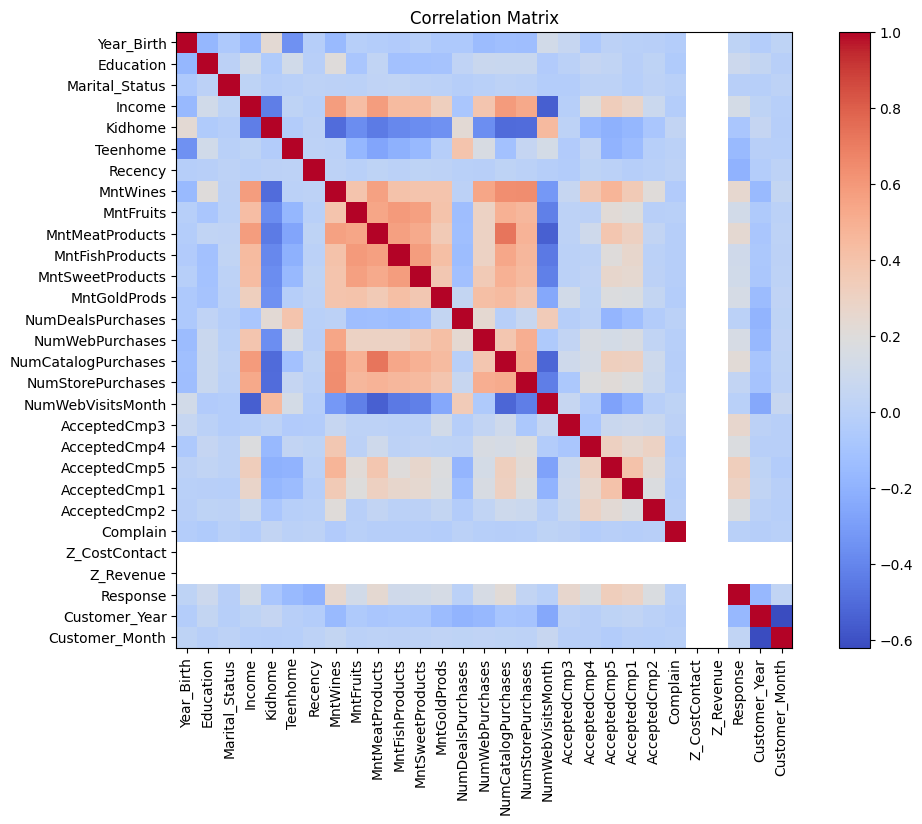

In [22]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

# Step 11: Define Features and Target

We use all columns except Income as input features.
Income will be our target variable.

In [23]:
X = df.drop("Income", axis=1)

y = df["Income"]

# Step 12: Split the Dataset

Split the dataset into training and testing sets.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 13: Train Linear Regression Model

Train the model using the training data.

In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](28,)","[ -52.43, 812.64, 3.08,...,-972. ,1100.1 , 81.19]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](28,)","['Year_Birth','Education','Marital_Status',...,'Response','Customer_Year', 'Customer_Month']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.067e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,28
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,26


# Step 14: Make Predictions

Predict Income using the testing data.

In [26]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[49197.1891533  54837.54542853 32460.88297359 96466.21553386
 69935.33427545 63600.41071589 63668.08363162 68134.98001937
 30103.85756264 42457.57461935]


# Step 15: Model Evaluation

Evaluate the model using MAE, MSE, RMSE, and R² Score.

In [27]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 6730.390613900994
MSE : 96603129.71834542
RMSE: 9828.689114950448
R2 Score: 0.7733249594917913


# Step 16: Compare Actual and Predicted Values

Create a table showing actual and predicted income values.

In [28]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
324,40464.0,49197.189153
96,47916.0,54837.545429
2104,14188.0,32460.882974
1259,76653.0,96466.215534
1061,65196.0,69935.334275
1805,53977.0,63600.410716
916,73113.0,63668.083632
350,71113.0,68134.980019
1901,22148.0,30103.857563
1650,22448.0,42457.574619


# Step 17: Actual vs Predicted Visualization

This plot helps us compare actual values
with predicted values.

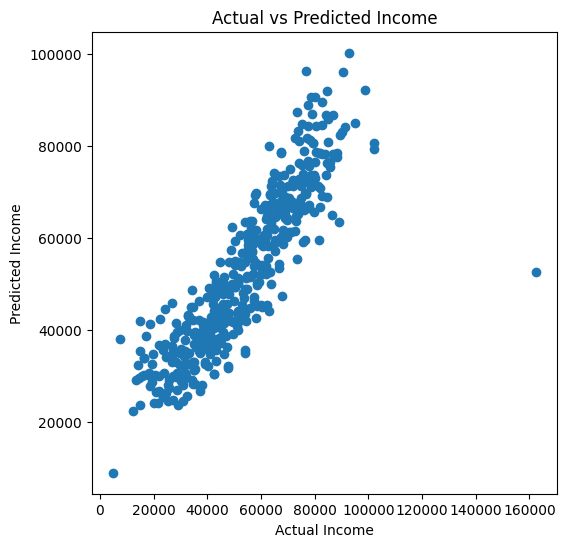

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Income")

plt.ylabel("Predicted Income")

plt.title("Actual vs Predicted Income")

plt.show()

# Step 18: Residual Analysis

Residuals are the differences between
actual and predicted values.

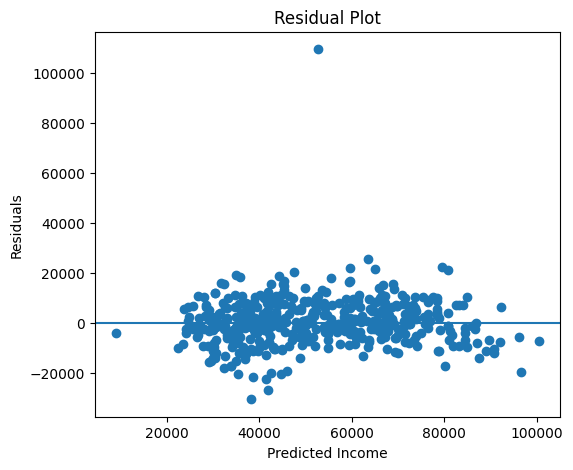

In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Income")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# Step 19: Save the Model

Save the trained Linear Regression model for future use.

In [30]:
joblib.dump(model, "linear_regression_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Step 20: Predict One Sample

Use one testing sample to make a prediction.

In [31]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

print("Predicted Income:", prediction[0])

Predicted Income: 49197.1891532992
